Bo'sh joylar qoldimi: 0


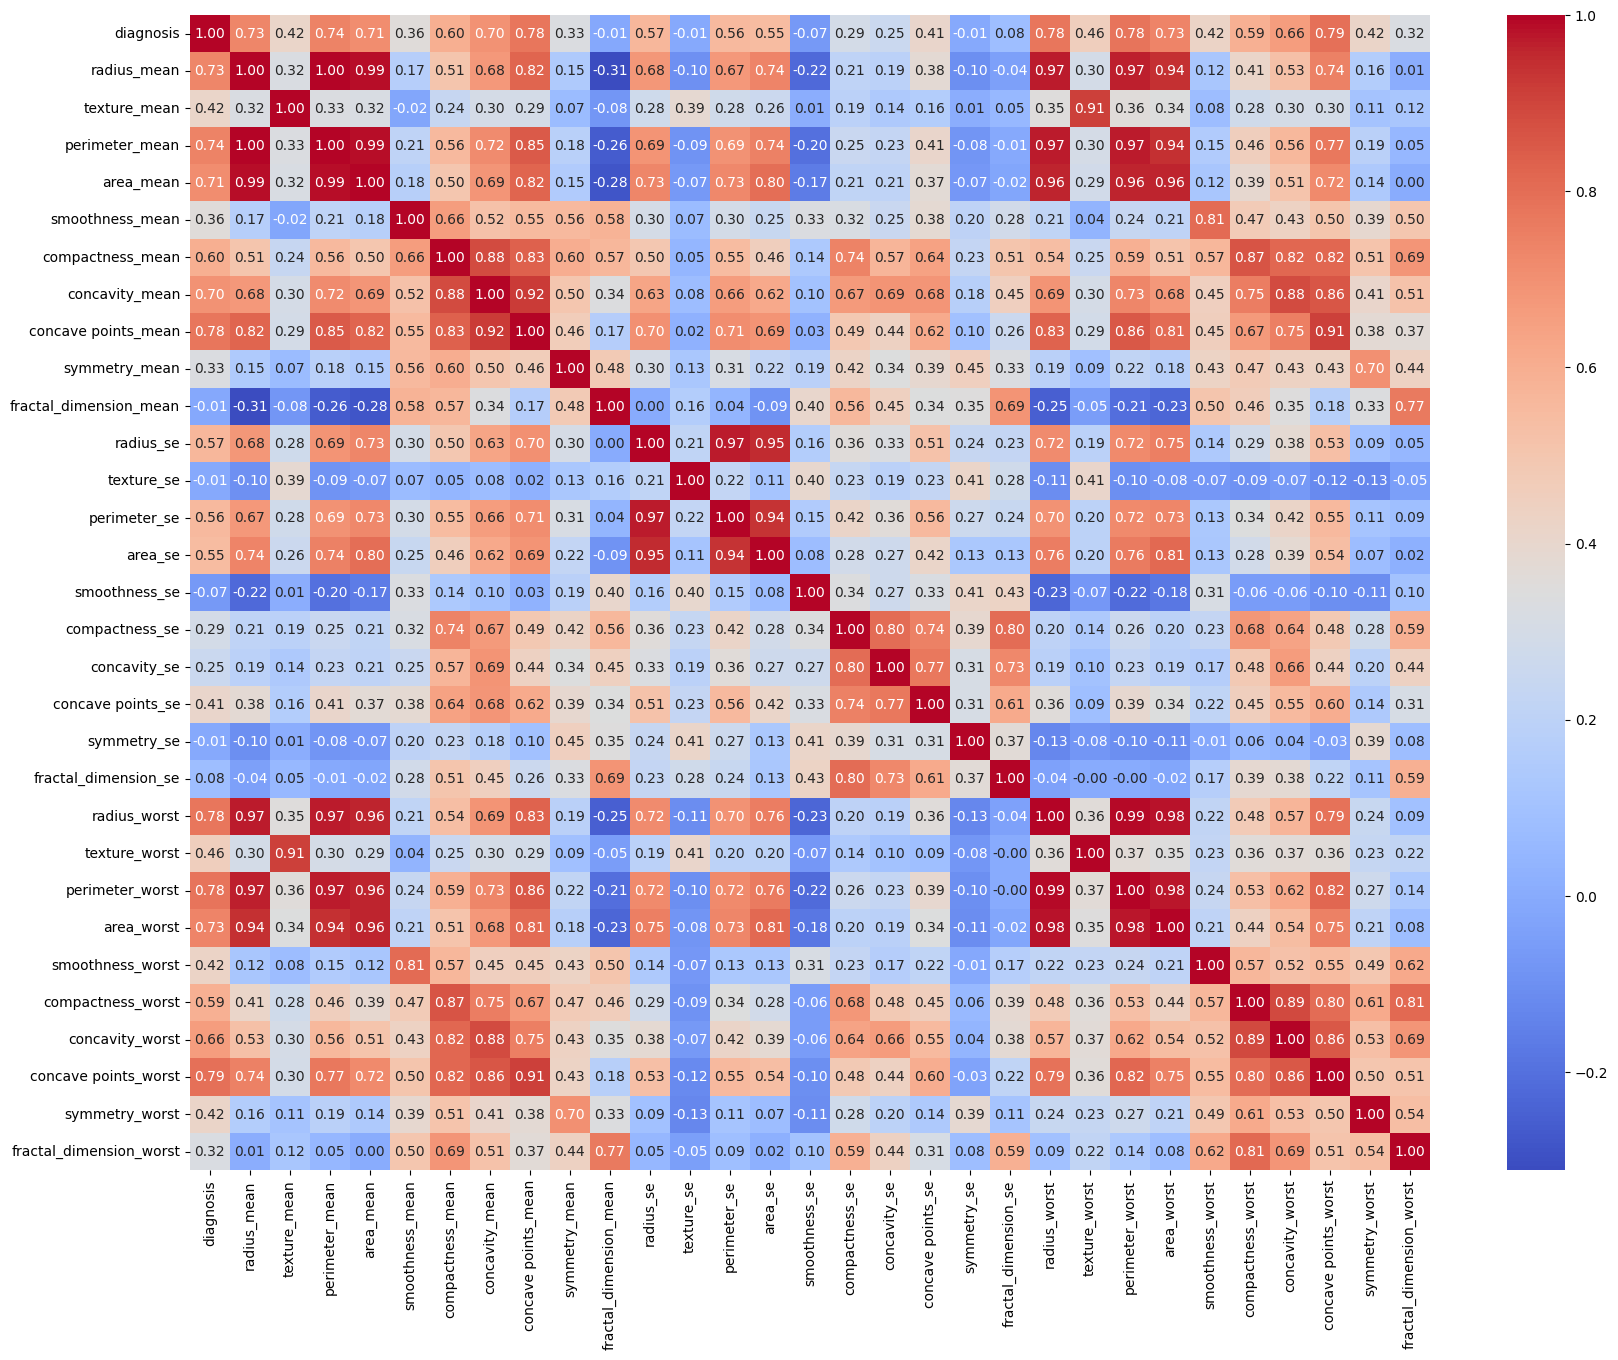

NameError: name 'np' is not defined

In [ ]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , confusion_matrix
data = pd.read_csv("fayl.csv")
data.head()
data.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore', inplace=True)
data.head()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])
data.head()
from sklearn.impute import KNNImputer
imputer = KNNImputer()
df_filled = imputer.fit_transform(data)
df_final = pd.DataFrame(df_filled, columns=data.columns)

print("Bo'sh joylar qoldimi:", df_final.isnull().sum().sum())
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df_final.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.savefig("CorrelationDegree.png")
plt.show()

upper = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

print("O'chirilishi kerak bo'lgan (bir-birini takrorlovchi) ustunlar:", to_drop)

df_selected = df_final.drop(to_drop, axis=1)
data.head()
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Ma'lumotni yuklash
df = pd.read_csv('KNNAlgorithmDataset.csv')

# 2. Tozalash (Cleaning)
# 'id' va oxiridagi bo'sh ustunni o'chiramiz
df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore', inplace=True)
# Diagnozni songa o'tkazamiz: M -> 1, B -> 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# 3. Korrelyatsiya orqali o'ta o'xshash ustunlarni o'chirish
# (Modelimiz yengil va aniq bo'lishi uchun)
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
df_final = df.drop(to_drop, axis=1)

# 4. Train va Test'ga bo'lish
X = df_final.drop('diagnosis', axis=1)
y = df_final['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Modelni o'qitish
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# 7. Model aniqligini tekshirish
y_pred = knn.predict(X_test_scaled)
print(f"Model aniqligi: {accuracy_score(y_test, y_pred) * 100:.2f}%")

yangi_bemor = X_test.iloc[0:1] 

yangi_bemor_scaled = scaler.transform(yangi_bemor)

bashorat = knn.predict(yangi_bemor_scaled)
ehtimollik = knn.predict_proba(yangi_bemor_scaled) 

print("\n--- Yangi obyekt uchun natija ---")
if bashorat[0] == 1:
    print("Tashxis: Malignant")
else:
    print("Tashxis: Benign")

print(f"Ishonch darajasi: {np.max(ehtimollik) * 100}%")